In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Libraries

In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# Shuffling images inside a folder

In [3]:
def rename_files(folder_path, prefix):
    files = os.listdir(folder_path)

    for i, file_name in enumerate(files, start=1):
        source_path = os.path.join(folder_path, file_name)
        if os.path.isfile(source_path):

            new_name = f"{prefix}{i}{os.path.splitext(file_name)[1]}"
            dest_path = os.path.join(folder_path, new_name)
            os.rename(source_path, dest_path)

    print(f"{len(files)} files renamed in {folder_path}")



In [4]:
# rename images of ampersand folder
folder_path = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/ampersand cropped"
rename_files(folder_path, 'ampersand')

356 files renamed in /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/ampersand cropped


In [5]:
# rename images of at sign folder
folder_path = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/at sign cropped"
rename_files(folder_path, 'at sign')

323 files renamed in /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/at sign cropped


In [6]:
# rename images of dollar sign folder
folder_path = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/dollar sign cropped"
rename_files(folder_path, 'dollar sign')

413 files renamed in /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/dollar sign cropped


In [7]:
# Importing this library for making copies
import shutil


In [8]:
def copy_files(source_folder, destination_folder):
    files = os.listdir(source_folder)

    for file_name in files:
        source_path = os.path.join(source_folder, file_name)
        dest_path = os.path.join(destination_folder, file_name)

        if os.path.isfile(source_path):
            shutil.copy2(source_path, dest_path)

    print(f"{len(files)} files copied from {source_folder} to {destination_folder}")


In [9]:
# copying pictures of ampersand
source_folder = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/ampersand cropped"
destination_folder = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images"
copy_files(source_folder, destination_folder)

356 files copied from /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/ampersand cropped to /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images


In [10]:
# copying pictures of at sign
source_folder = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/at sign cropped"
destination_folder = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images"
copy_files(source_folder, destination_folder)

323 files copied from /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/at sign cropped to /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images


In [11]:
# copying pictures of dollar sign
source_folder = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/dollar sign cropped"
destination_folder = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images"
copy_files(source_folder, destination_folder)

413 files copied from /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/dollar sign cropped to /content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images


In [ ]:
import random

folder_path = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images"

images = os.listdir(folder_path)
random.shuffle(images)

print("Shuffled images:")
for image in images:
    print(image)

In [13]:
text_file_path = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/lables.txt"
with open(text_file_path, "w") as file:
    for image in images:
        if "at sign" in image:
            file.write("1\n")
        elif "dollar sign" in image:
            file.write("2\n")
        elif "ampersand" in image:
            file.write("3\n")


In [14]:
print(f"number of images: {len(images)}")

number of images: 1092


In [15]:
def reading_images_and_labels(folder_path, text_file_path):
    data = []

    with open(text_file_path, "r") as f:
        labels = [int(line.strip()) for line in f.readlines()]

    images = os.listdir(folder_path)


    for image in images:
        image_path = os.path.join(folder_path, image)
        image = cv.imread(image_path)
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

        resized_image = cv.resize(image, (50, 50), interpolation=cv.INTER_AREA) #inter_area method has choosen because it has the best performance on reducing size of images
        data.append(resized_image)

    data = np.array(data)
    labels = np.array(labels)
    return data, labels




In [16]:
folder_path = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/Images"
text_file_path = "/content/drive/Othercomputers/My Laptop/ML-Beheshti/Assignments/7- Nueral Network/lables.txt"
data, labels = reading_images_and_labels(folder_path, text_file_path)


In [17]:
labels -= 1

In [18]:
m = data.shape[0]
train_size = int(0.8*m)
test_size = m - train_size


In [19]:
train_size

873

In [20]:
test_size

219

In [21]:
import random

train_indices = random.sample(range(m), train_size)
train_indices = np.array(train_indices)
test_indices = np.delete(np.arange(m), train_indices)

In [22]:
# train_indices
# test_indices

In [23]:
x_train = data[train_indices]
y_train = labels[train_indices]

x_test = data[test_indices]
y_test = labels[test_indices]

In [24]:
x_train_norm = x_train / 255
x_test_norm = x_test / 255

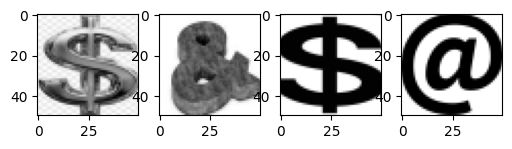

In [25]:
fig, ax = plt.subplots(1, 4, figsize = (6, 2))
ax[0].imshow(x_train[0], cmap = 'gray')
ax[1].imshow(x_train[1], cmap = 'gray')
ax[2].imshow(x_train[2], cmap = 'gray')
ax[3].imshow(x_train[3], cmap = 'gray')

In [26]:
model = Sequential(layers = [
    tf.keras.Input(shape = (x_train_norm.shape[1] * x_train_norm.shape[2], )),
    Dense(units = 60, activation = 'relu'),
    Dense(units = 50, activation = 'relu'),
    Dense(units = 70, activation = 'relu'),
    Dense(units = 60, activation = 'relu'),
    Dense(units = 50, activation = 'relu'),
    Dense(units = 80, activation = 'relu'),
    Dense(units = 70, activation = 'relu'),
    Dense(units = 60, activation = 'relu'),
    Dense(units = 80, activation = 'relu'),
    Dense(units = 60, activation = 'relu'),
    Dense(units = 3, activation = 'softmax')
])

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 60)                  │         150,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           3,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 70)                  │           3,570 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 60)                  │           4,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 50)                  │           3,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 80)                  │           4,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 70)                  │           5,670 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 60)                  │           4,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 80)                  │           4,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 60)                  │           4,860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 3)                   │             183 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 187,923 (734.07 KB)

 Trainable params: 187,923 (734.07 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001)
)

In [29]:
model.fit(
    x = x_train_norm.reshape((-1,x_train_norm.shape[1] * x_train_norm.shape[2])),
    y = y_train,
    epochs = 100,
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 1.0950
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0922
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0880
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0900
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0936
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0975
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0960
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0914
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0812
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0877
Epoch 11/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0891
Epoch 12/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0809
Epoch 13/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0819
Epoch 14/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0807
Epoch 15/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0851
Epo

In [30]:
prediction = model.predict(x_test_norm.reshape(x_test_norm.shape[0], -1))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


In [31]:
# prediction.shape
# prediction

In [32]:
def compute_label(pred):
  label = []
  for i in range(len(pred)):
    label.append(pred[i].argmax())

  return np.array(label)

In [33]:
predicted_labels = compute_label(prediction)

In [34]:
def compute_accuracy(label, y):
  corrects = 0
  for i in range(len(label)):
    corrects += 1 if label[i] == y[i] else 0

  return corrects / len(label)

In [35]:
compute_accuracy(predicted_labels, y_test)

0.3378995433789954

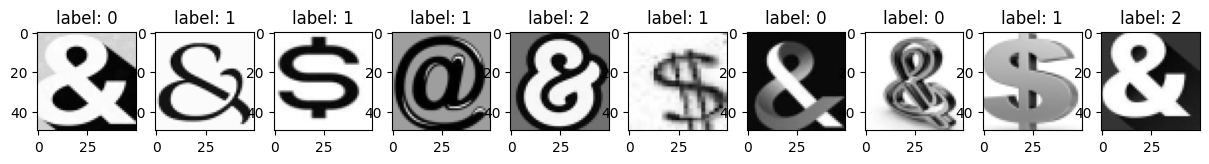

In [36]:
rand = np.random.randint(0, x_test.shape[0], 10)
fig, ax = plt.subplots(1, len(rand), figsize = (15, 2))

for i in range(len(rand)):
  ax[i].imshow(x_test[rand[i]], cmap = 'gray')
  ax[i].set_title(f'label: {(predicted_labels[rand[i]])}')